In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from tqdm import tqdm

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
from tqdm.notebook import tqdm
import joblib
from time import perf_counter

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
RANDOM_STATE = 42

In [7]:
# Paths
SAT_PATH   = "/Users/jjburrell/Downloads/EE_harvest_ml.csv"  # your feature file
YIELD_PATH = "/Users/jjburrell/Downloads/Plot_dataset.dta"  # yield file

print("🔹 Loading data...")
sat_df   = pd.read_csv(SAT_PATH)
yield_df = pd.read_stata(YIELD_PATH)

# Filter invalid yields
yield_df = yield_df[(yield_df["yield_kg"] > 0) & (yield_df["yield_kg"] < 15000)]
yield_df = yield_df.dropna(subset=["yield_kg", "lat_modified", "lon_modified"])

# Aggregate yields at same spatial location
agg_yield = (
    yield_df.groupby(["country", "wave", "season", "lat_modified", "lon_modified"])
    .agg(mean_yield=("yield_kg", "mean"))
    .reset_index()
)

# Log-transform the target
agg_yield["log_yield"] = np.log1p(agg_yield["mean_yield"])

print("Yield shape:", agg_yield.shape)
print("Sat shape:", sat_df.shape)

# Merge features + yields
df = pd.merge(
    agg_yield,
    sat_df,
    on=["country", "wave", "season", "lat_modified", "lon_modified"],
    how="inner"
)

df = df.dropna()
print("✅ Final merged dataset:", df.shape)

df.to_csv("merged_dataset_for_training.csv", index=False)
print("Saved → merged_dataset_for_training.csv")


🔹 Loading data...
Yield shape: (4815, 7)
Sat shape: (9007, 89)
✅ Final merged dataset: (2514, 91)
Saved → merged_dataset_for_training.csv


/var/folders/kh/hkkfd68s6mb8b11z27mn1b4h0000gn/T/ipykernel_63422/2380638205.py:7: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  yield_df = pd.read_stata(YIELD_PATH)


In [8]:
TARGET_COL = "log_yield"
y = df[TARGET_COL]

# Remove country + target from feature matrix
X = df.drop(columns=["country", "mean_yield", "log_yield"])

countries = df["country"].unique()
print("Countries found:", countries)


Countries found: ['Ethiopia' 'Malawi' 'Mali' 'Nigeria' 'Tanzania' 'Uganda']


In [9]:
def build_rf():
    return RandomForestRegressor(
        n_estimators=500,
        max_depth=20,
        min_samples_leaf=1,
        min_samples_split=2,
        max_features=0.8,
        n_jobs=-1,
        random_state=42
    )

def build_xgb():
    return XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        tree_method="hist",
        n_jobs=-1,
        random_state=42
    )


In [10]:
print("\n🔧 Training GLOBAL models...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

global_models = {}

for model_name in tqdm(["RF", "XGB"], desc="Training Global Models"):
    if model_name == "RF":
        model = build_rf()
    else:
        model = build_xgb()

    model.fit(X_train, y_train)
    global_models[model_name] = model

# Save models
joblib.dump(global_models["RF"],  "model_GLOBAL_RF.joblib")
joblib.dump(global_models["XGB"], "model_GLOBAL_XGB.joblib")

print("Saved global models locally.")



🔧 Training GLOBAL models...


Training Global Models: 100%|██████████| 2/2 [00:03<00:00,  1.86s/it]

Saved global models locally.


In [11]:
results = []

print("\n📊 Evaluating GLOBAL models on each country...")
for c in tqdm(countries, desc="Global Evaluation"):
    mask = df["country"] == c
    Xc = X.loc[mask]
    yc = y.loc[mask]

    pred_rf  = global_models["RF"].predict(Xc)
    pred_xgb = global_models["XGB"].predict(Xc)

    results.append({"country": c, "model": "Global_RF", "r2": r2_score(yc, pred_rf)})
    results.append({"country": c, "model": "Global_XGB", "r2": r2_score(yc, pred_xgb)})



📊 Evaluating GLOBAL models on each country...


Global Evaluation: 100%|██████████| 6/6 [00:00<00:00, 30.60it/s]


In [12]:
print("\n🔧 Training COUNTRY-SPECIFIC models...")

country_models = {}

for c in tqdm(countries, desc="Country-Specific Training"):
    mask = df["country"] == c
    Xc = X.loc[mask]
    yc = y.loc[mask]

    if len(Xc) < 50:
        print(f"Skipping {c} (not enough samples: {len(Xc)})")
        continue

    rf  = build_rf()
    xgb = build_xgb()

    rf.fit(Xc, yc)
    xgb.fit(Xc, yc)

    # Save models locally
    joblib.dump(rf,  f"model_{c}_RF.joblib")
    joblib.dump(xgb, f"model_{c}_XGB.joblib")

    # Evaluate on same-country data
    results.append({"country": c, "model": "Country_RF",  "r2": r2_score(yc, rf.predict(Xc))})
    results.append({"country": c, "model": "Country_XGB", "r2": r2_score(yc, xgb.predict(Xc))})

print("All country-specific models saved.")



🔧 Training COUNTRY-SPECIFIC models...


Country-Specific Training: 100%|██████████| 6/6 [00:10<00:00,  1.75s/it]

All country-specific models saved.


In [16]:
print("\n🔧 Training COUNTRY-SPECIFIC models...")

country_models = {}

for c in tqdm(countries, desc="Country-Specific Training"):
    mask = df["country"] == c
    Xc = X.loc[mask]
    yc = y.loc[mask]

    if len(Xc) < 50:
        print(f"Skipping {c} (not enough samples: {len(Xc)})")
        continue

    rf  = build_rf()
    xgb = build_xgb()

    rf.fit(Xc, yc)
    xgb.fit(Xc, yc)

    # Save models locally
    joblib.dump(rf,  f"model_{c}_RF.joblib")
    joblib.dump(xgb, f"model_{c}_XGB.joblib")

    # Evaluate on same-country data
    results.append({"country": c, "model": "Country_RF",  "r2": r2_score(yc, rf.predict(Xc))})
    results.append({"country": c, "model": "Country_XGB", "r2": r2_score(yc, xgb.predict(Xc))})

print("All country-specific models saved.")



🔧 Training COUNTRY-SPECIFIC models...


Country-Specific Training: 100%|██████████| 6/6 [00:10<00:00,  1.69s/it]

All country-specific models saved.


Saved → country_model_comparison.csv
    country       model        r2
0  Ethiopia   Global_RF  0.638771
1  Ethiopia  Global_XGB  0.720047
2    Malawi   Global_RF  0.617426
3    Malawi  Global_XGB  0.685231
4      Mali   Global_RF  0.690991

Counts per (country, model):
country   model      
Ethiopia  Country_RF     2
          Country_XGB    2
          Global_RF      1
          Global_XGB     1
Malawi    Country_RF     2
          Country_XGB    2
          Global_RF      1
          Global_XGB     1
Mali      Country_RF     2
          Country_XGB    2
          Global_RF      1
          Global_XGB     1
Nigeria   Country_RF     2
          Country_XGB    2
          Global_RF      1
          Global_XGB     1
Tanzania  Country_RF     2
          Country_XGB    2
          Global_RF      1
          Global_XGB     1
Uganda    Country_RF     2
          Country_XGB    2
          Global_RF      1
          Global_XGB     1
dtype: int64


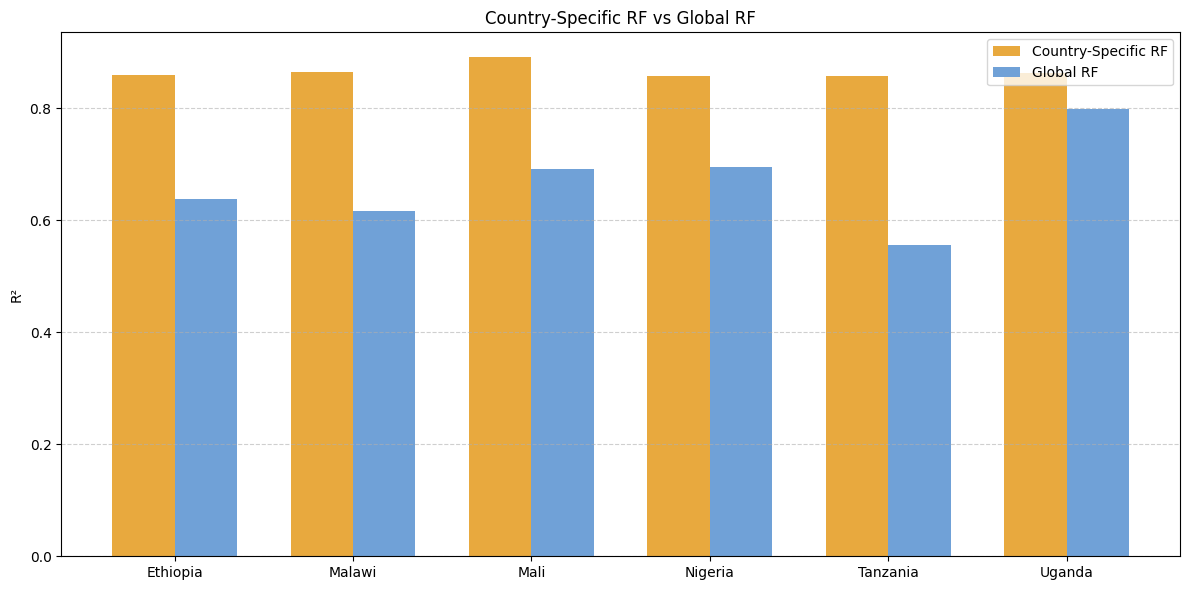

Saved → country_vs_global_models.png


In [ ]:
# ----------------------------------------------------------
# 8. Save summary + PLOTS for RF + XGB
# ----------------------------------------------------------
results_df = pd.DataFrame(results)
results_df.to_csv("country_model_comparison.csv", index=False)

print("Saved → country_model_comparison.csv")
print(results_df.head())

# Use pivot_table to avoid duplicate index errors
pivot_plot = results_df.pivot_table(
    index="country",
    columns="model",
    values="r2",
    aggfunc="mean"
)

# -------------------------------
# PLOT 1: RF Comparison
# -------------------------------
plt.figure(figsize=(12, 6))
x = np.arange(len(pivot_plot.index))
width = 0.35

plt.bar(
    x - width/2,
    pivot_plot["Country_RF"],
    width,
    label="Country-Specific RF",
    color="#E8A93E"
)
plt.bar(
    x + width/2,
    pivot_plot["Global_RF"],
    width,
    label="Global RF",
    color="#70A1D7"
)

plt.xticks(x, pivot_plot.index, rotation=45)
plt.ylabel("R²")
plt.title("Country-Specific vs Global (Random Forest)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("country_vs_global_RF.png", dpi=300)
plt.show()

print("Saved → country_vs_global_RF.png")

# -------------------------------
# PLOT 2: XGBoost Comparison
# -------------------------------
plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2,
    pivot_plot["Country_XGB"],
    width,
    label="Country-Specific XGB",
    color="#FFB347"  # orange-gold
)
plt.bar(
    x + width/2,
    pivot_plot["Global_XGB"],
    width,
    label="Global XGB",
    color="#6FA8DC"  # lighter blue
)

plt.xticks(x, pivot_plot.index, rotation=45)
plt.ylabel("R²")
plt.title("Country-Specific vs Global (XGBoost)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("country_vs_global_XGB.png", dpi=300)
plt.show()

print("Saved → country_vs_global_XGB.png")


Saved → country_model_comparison.csv
Unique model labels: ['Global_RF' 'Global_XGB' 'Country_RF' 'Country_XGB']

Columns in pivot_plot: ['Country_RF', 'Country_XGB', 'Global_RF', 'Global_XGB']


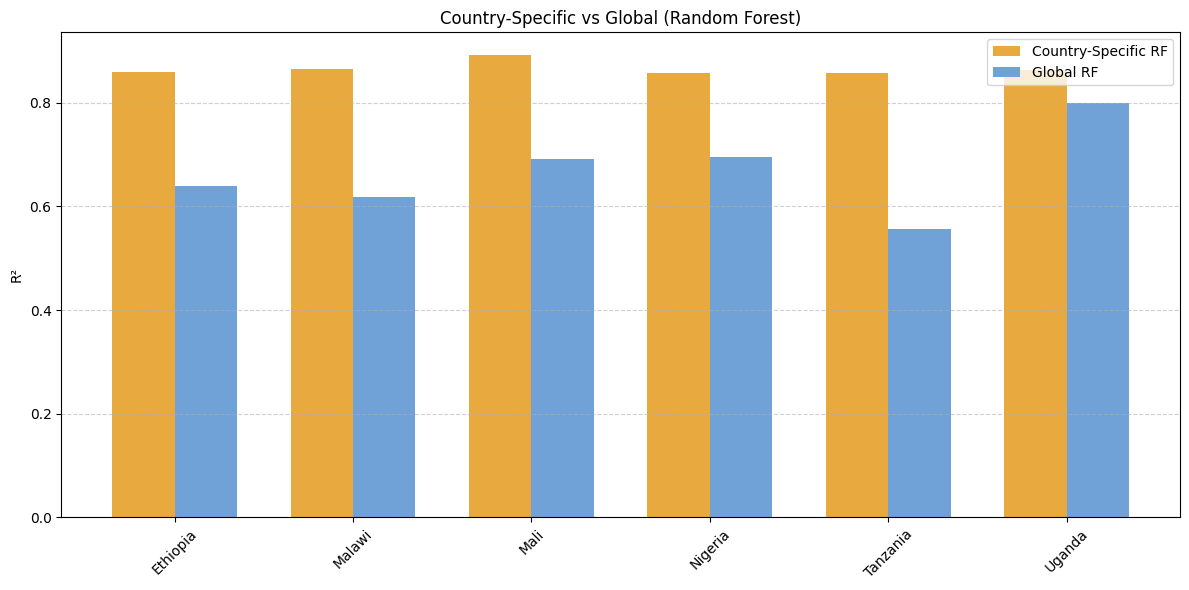

Saved → country_vs_global_RF.png


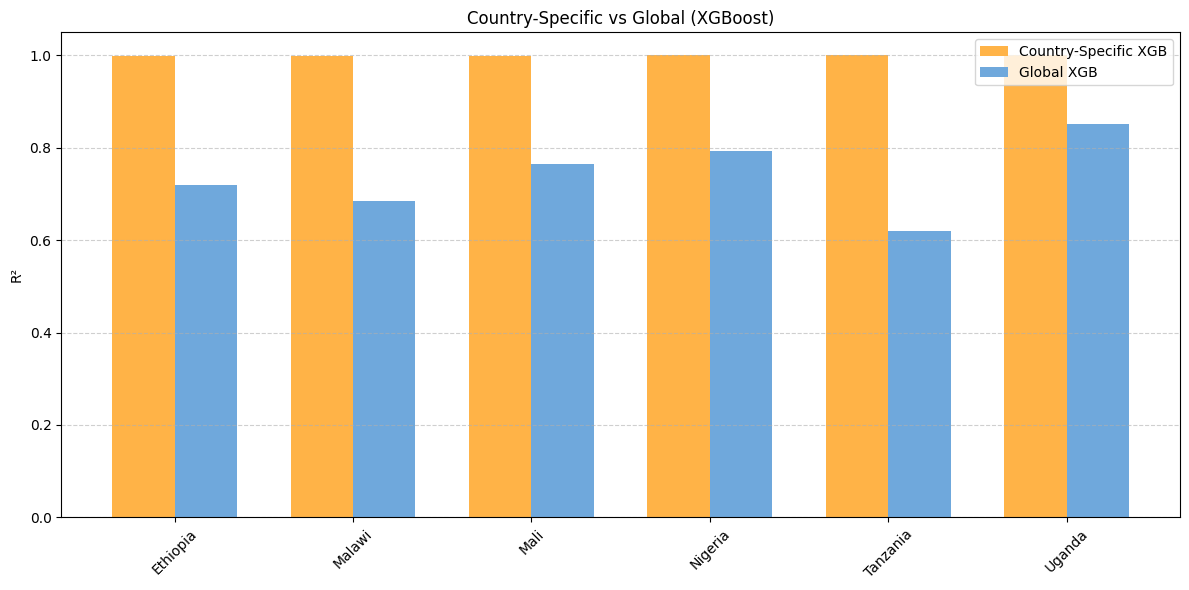

Saved → country_vs_global_XGB.png


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------------------------------------
# Final summary + RF & XGB plots
# ----------------------------------------------------------
results_df = pd.DataFrame(results)
results_df.to_csv("country_model_comparison.csv", index=False)

print("Saved → country_model_comparison.csv")
print("Unique model labels:", results_df["model"].unique())

pivot_plot = results_df.pivot_table(
    index="country",
    columns="model",
    values="r2",
    aggfunc="mean"
)

print("\nColumns in pivot_plot:", pivot_plot.columns.tolist())

# -------------------------------
# PLOT 1: Random Forest
# -------------------------------
plt.figure(figsize=(12, 6))
x = np.arange(len(pivot_plot.index))
width = 0.35

plt.bar(
    x - width/2,
    pivot_plot["Country_RF"],
    width,
    label="Country-Specific RF",
    color="#E8A93E",
)
plt.bar(
    x + width/2,
    pivot_plot["Global_RF"],
    width,
    label="Global RF",
    color="#70A1D7",
)

plt.xticks(x, pivot_plot.index, rotation=45)
plt.ylabel("R²")
plt.title("Country-Specific vs Global (Random Forest)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("country_vs_global_RF.png", dpi=300)
plt.show()
print("Saved → country_vs_global_RF.png")

# -------------------------------
# PLOT 2: XGBoost  (only if data exists)
# -------------------------------
if {"Country_XGB", "Global_XGB"}.issubset(pivot_plot.columns):
    plt.figure(figsize=(12, 6))

    plt.bar(
        x - width/2,
        pivot_plot["Country_XGB"],
        width,
        label="Country-Specific XGB",
        color="#FFB347",
    )
    plt.bar(
        x + width/2,
        pivot_plot["Global_XGB"],
        width,
        label="Global XGB",
        color="#6FA8DC",
    )

    plt.xticks(x, pivot_plot.index, rotation=45)
    plt.ylabel("R²")
    plt.title("Country-Specific vs Global (XGBoost)")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.savefig("country_vs_global_XGB.png", dpi=300)
    plt.show()
    print("Saved → country_vs_global_XGB.png")
else:
    print("\n⚠️ No XGB results found in pivot_plot; available models are:")
    print(pivot_plot.columns.tolist())


In [18]:
# ==========================================================
# Yield Model (GPU, cuML RF):
# Spatial CV for tuning + Wave-based Train/Test Split
# NeurIPS-style: clear train/test + nice seaborn plots
# ==========================================================

import os
import pandas as pd
import numpy as np

from cuml.ensemble import RandomForestRegressor as cuRF
from sklearn.model_selection import GroupKFold, ParameterGrid
from sklearn.metrics import r2_score, mean_squared_error
from tqdm.notebook import tqdm
import joblib
from time import perf_counter

import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# 0. Paths and output directory
# ----------------------------------------------------------
sat_path = "/content/drive/MyDrive/Research/Crop Yield Prediction/EE_harvest_ml.csv"
yield_path = "/content/drive/MyDrive/Research/Crop Yield Prediction/LSMS Data/Plot_dataset.dta"

model_dir = "/content/drive/MyDrive/Research/Crop Yield Prediction/models_gpu_spatialcv_waveholdout"
os.makedirs(model_dir, exist_ok=True)

sns.set_theme(style="whitegrid")

# ----------------------------------------------------------
# 1. Load and preprocess data
# ----------------------------------------------------------
print("🔹 Loading datasets...")
yield_df = pd.read_stata(yield_path)
sat_df = pd.read_csv(sat_path)

# Filter out implausible yields
yield_df = yield_df[(yield_df["yield_kg"] > 0) & (yield_df["yield_kg"] < 15000)]
yield_df = yield_df.dropna(subset=["yield_kg", "lat_modified", "lon_modified"])

# Aggregate to (country, wave, season, lat, lon)
agg_yields = (
    yield_df.groupby(["country", "wave", "season", "lat_modified", "lon_modified"])
    .agg(mean_yield=("yield_kg", "mean"))
    .reset_index()
)

# Log-transform target
agg_yields["log_yield"] = np.log1p(agg_yields["mean_yield"])

# Merge with satellite data
df = pd.merge(
    agg_yields,
    sat_df,
    on=["country", "wave", "season", "lat_modified", "lon_modified"],
    how="inner",
)

df = df.dropna()
print(f"✅ Final merged shape: {df.shape}")

# ----------------------------------------------------------
# 2. Define variables and outer train/test split
#    Outer split = hold out last wave as test
# ----------------------------------------------------------
merge_vars = ["country", "wave", "season", "lat_modified", "lon_modified"]
y_var = "log_yield"
x_vars = [c for c in df.columns if c not in merge_vars + ["mean_yield", "log_yield"]]

X_full = df[x_vars]
y_full = df[y_var]

# Spatial groups for inner CV
groups_full = (
    df["country"].astype(str)
    + "_"
    + df["wave"].astype(str)
    + "_"
    + df["lat_modified"].astype(str)
    + "_"
    + df["lon_modified"].astype(str)
)

cv = GroupKFold(n_splits=5)

# Outer split: hold out final wave
test_wave = df["wave"].max()
print(f"📌 Using wave={test_wave} as held-out TEST set.")

train_mask = df["wave"] != test_wave
test_mask = df["wave"] == test_wave

X_train, y_train, groups_train = (
    X_full.loc[train_mask],
    y_full.loc[train_mask],
    groups_full.loc[train_mask],
)
X_test, y_test, groups_test = (
    X_full.loc[test_mask],
    y_full.loc[test_mask],
    groups_full.loc[test_mask],
)

countries = df["country"].unique()
print("Countries:", countries)

# ----------------------------------------------------------
# 3. Parameter grid
# ----------------------------------------------------------
param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [12, 20, 32],
    "max_features": [0.5, 0.8],
    "min_samples_split": [2, 8],
    "min_samples_leaf": [1, 4],
    "bootstrap": [True],
}
grid_list = list(ParameterGrid(param_grid))
rng = np.random.default_rng(42)
grid_list = [grid_list[i] for i in rng.permutation(len(grid_list))]
print(f"Total parameter combos (shuffled): {len(grid_list)}")

# ----------------------------------------------------------
# 4. Helper functions: tuning + fitting
# ----------------------------------------------------------
def tune_with_spatial_cv_cuml(
    X, y, groups, grid_list,
    patience=15, min_delta=1e-3, desc_label="Tuning"
):
    """
    Inner-loop tuning using GroupKFold spatial CV, run ONLY on training data.
    """
    best_r2 = -np.inf
    best_params = None
    no_improve = 0
    start = perf_counter()

    for p in tqdm(grid_list, desc=desc_label, ncols=100):
        r2_fold = []
        rmse_fold = []

        for tr_idx, va_idx in cv.split(X, y, groups):
            rf = cuRF(
                n_estimators=p["n_estimators"],
                max_depth=p["max_depth"],
                max_features=p["max_features"],
                min_samples_split=p["min_samples_split"],
                min_samples_leaf=p["min_samples_leaf"],
                bootstrap=p["bootstrap"],
                n_streams=4,
                random_state=42,
            )
            rf.fit(X.iloc[tr_idx], y.iloc[tr_idx])
            pred = rf.predict(X.iloc[va_idx])
            r2_fold.append(r2_score(y.iloc[va_idx], pred))
            rmse_fold.append(np.sqrt(mean_squared_error(y.iloc[va_idx], pred)))

        r2_mean = float(np.mean(r2_fold))

        if r2_mean > best_r2 + min_delta:
            best_r2 = r2_mean
            best_params = p
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"⏹️ Early stopping after {no_improve} non-improving combos.")
                break

    elapsed = perf_counter() - start
    print(f"✅ Best CV R²={best_r2:.3f} | time={elapsed:.1f}s")
    return best_params, best_r2


def fit_best_cuml_model(X, y, best_params):
    """
    Fit cuML RF with best hyperparameters on given data (train only for NeurIPS).
    """
    rf = cuRF(
        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        max_features=best_params["max_features"],
        min_samples_split=best_params["min_samples_split"],
        min_samples_leaf=best_params["min_samples_leaf"],
        bootstrap=best_params["bootstrap"],
        n_streams=4,
        random_state=42,
    )
    rf.fit(X, y)
    return rf

# ----------------------------------------------------------
# 5. Global model: tune on train, evaluate on held-out test
# ----------------------------------------------------------
print("\n🔧 Tuning GLOBAL model on TRAIN (spatial CV)...")
best_params_global, best_cv_r2_global = tune_with_spatial_cv_cuml(
    X_train, y_train, groups_train, grid_list,
    patience=12, min_delta=1e-3, desc_label="GLOBAL"
)
print("Best GLOBAL params:", best_params_global)
print(f"GLOBAL inner-CV R² (train domain): {best_cv_r2_global:.3f}")

global_model = fit_best_cuml_model(X_train, y_train, best_params_global)
joblib.dump(global_model, os.path.join(model_dir, "model_GLOBAL.joblib"))

# Evaluate global model on held-out test wave, per country
test_results = []
for c in countries:
    mask_c_test = (df["country"] == c) & test_mask
    Xc_test = X_full.loc[mask_c_test]
    yc_test = y_full.loc[mask_c_test]

    if len(Xc_test) == 0:
        continue

    y_pred = global_model.predict(Xc_test)
    r2 = r2_score(yc_test, y_pred)
    rmse = np.sqrt(mean_squared_error(yc_test, y_pred))

    test_results.append({
        "train_model": "GLOBAL",
        "test_country": c,
        "split": "test",
        "r2": r2,
        "rmse": rmse,
    })

# ----------------------------------------------------------
# 6. Per-country models: tune on that country's train subset
#    and evaluate on that country's held-out test wave
# ----------------------------------------------------------
country_models = {}

for c in countries:
    mask_c_train = (df["country"] == c) & train_mask
    mask_c_test  = (df["country"] == c) & test_mask

    Xc_train = X_full.loc[mask_c_train]
    yc_train = y_full.loc[mask_c_train]
    groups_c_train = groups_full.loc[mask_c_train]

    Xc_test = X_full.loc[mask_c_test]
    yc_test = y_full.loc[mask_c_test]

    if len(Xc_train) < 50 or len(Xc_test) < 10:
        print(f"⚠️ Skipping {c}: insufficient train/test samples "
              f"(train={len(Xc_train)}, test={len(Xc_test)}).")
        continue

    print(f"\n🔧 Tuning {c} model on TRAIN (spatial CV)...")
    best_params_c, best_cv_r2_c = tune_with_spatial_cv_cuml(
        Xc_train, yc_train, groups_c_train, grid_list,
        patience=10, min_delta=1e-3, desc_label=c
    )
    print(f"Best {c} params:", best_params_c)
    print(f"{c} inner-CV R² (train domain): {best_cv_r2_c:.3f}")

    model_c = fit_best_cuml_model(Xc_train, yc_train, best_params_c)
    country_models[c] = {
        "model": model_c,
        "params": best_params_c,
        "cv_r2": best_cv_r2_c,
    }
    joblib.dump(model_c, os.path.join(model_dir, f"model_{c}.joblib"))

    # Evaluate on that country's held-out test wave
    y_pred_c = model_c.predict(Xc_test)
    r2_c = r2_score(yc_test, y_pred_c)
    rmse_c = np.sqrt(mean_squared_error(yc_test, y_pred_c))

    test_results.append({
        "train_model": c,
        "test_country": c,
        "split": "test",
        "r2": r2_c,
        "rmse": rmse_c,
    })

# ----------------------------------------------------------
# 7. Collect and save test results
# ----------------------------------------------------------
results_df = pd.DataFrame(test_results)
results_df.to_csv(os.path.join(model_dir, "waveholdout_test_results.csv"), index=False)
print("\n✅ Saved held-out test results → waveholdout_test_results.csv")
print(results_df.head())

# ----------------------------------------------------------
# 8. Pretty seaborn plots: Global vs Country models on TEST
# ----------------------------------------------------------
plot_df = results_df.copy()

# 8a. Bar plot of R² by test country
plt.figure(figsize=(10, 5))
sns.barplot(
    data=plot_df,
    x="test_country",
    y="r2",
    hue="train_model",
    palette="Set2",
)
plt.title(f"Held-out Wave {test_wave}: R² by Country (GLOBAL vs Country-specific RF)")
plt.ylabel("R² (test)")
plt.xlabel("Test Country")
plt.xticks(rotation=45)
plt.legend(title="Train Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(model_dir, "test_r2_by_country.png"), dpi=300)
plt.show()

# 8b. Bar plot of RMSE by test country
plt.figure(figsize=(10, 5))
sns.barplot(
    data=plot_df,
    x="test_country",
    y="rmse",
    hue="train_model",
    palette="Set2",
)
plt.title(f"Held-out Wave {test_wave}: RMSE by Country (GLOBAL vs Country-specific RF)")
plt.ylabel("RMSE (test, log_yield units)")
plt.xlabel("Test Country")
plt.xticks(rotation=45)
plt.legend(title="Train Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(model_dir, "test_rmse_by_country.png"), dpi=300)
plt.show()

print(f"\nAll models & results saved in: {model_dir}")


ModuleNotFoundError: No module named 'cuml'